# **MLIS Practical 05**

**Name:** Yesha Pandya  
**Enrollment No:** 23BT04175  
**Division:** A
**Batch**: C

## **Objective**
To develop a machine learning model for predicting accident probability using IoT sensor data in Python.

## **Theoretical Overview**
Modern Intelligent Transportation Systems (ITS) utilize edge-computing IoT devices to continuously capture high-frequency telemetry from two primary sensor suites:
1. **In-Vehicle Telemetry Sensors**: Measure kinematic dynamics such as vehicle velocity, linear deceleration (braking $g$-force), lateral steering jitter, following distance (radar/LIDAR), and driver alertness levels.
2. **Environmental + Road Infrastructure Sensors:** Monitor micro-climate conditions such as ambient relative humidity, visual distance thresholds (optical fog sensors), crosswind velocity, and pavement friction/slip coefficients.

[![](https://mermaid.ink/img/pako:eNpVj21rwjAUhf_K5cJgg-q06qphCM4KE9wLKg627kNsrjXYJpKmbk7870vrNlk-ncs9zzk3B4y1IGS4SvVHvObGwjyMFLg3eItwrGoLWss4JZiRyrXJb5fmun852xIJDwZxTCkZbqVWHkzG4WB6FeE71Gp9GDp8JBKCkFsOgyQxlFRGeHSNznVquSttaieNVhkpy1MY6_n_svsik0LavQcLmculTCv9IpU4l53ChtUQusiHSXmcFC4Sno1e8hPmNAkZW23-DggrZuSYcK94JmN4Kuy2sAymMt_AhHaUwsWPHT1MjBTIrCnIw4xMxssRD-U2QrumzP2NOSm42UQYqaNjtly9ap39YkYXyRrZiqe5m4qt4JZCyRPDzxZSgsxQF8oi61QJyA74icxvB_WbRsP3251Wt9dttgIP98ja7Xqr6XZBM_D9Zq_bO3r4VXU26t2gc_wGOVSY-A?type=png)](https://mermaid.live/edit)

## **Mathematical Formulation**
### **I. Non-Linear Multi-Factor Interaction Score**
The ground truth probability of an accident $P(\text{Accident})$ is governed by non-linear physical interactions among kinematics and ambient physics. It is modeled as:
$$\text{Risk Index } (I) = w_1 \cdot \left(\frac{\text{Speed}}{\text{Friction} + 0.1}\right) + w_2 \cdot \left(\frac{\text{Wind Speed}}{\text{Visibility} + 0.1}\right) + w_3 \cdot \text{Braking Force} + w_4 \cdot \text{Fatigue Score} + w_5 \cdot \text{Humidity}$$


The raw index $I$ is mapped to a bounded percentage probability scale $[0, 100\%]$ using a Sigmoid logistic function:
$$P(\text{Accident}) = \left( \frac{1}{1 + e^{-k(I - x_0)}} \right) \times 100\% + \epsilon$$

Where
* $k$ is the scaling steepness
* $x_0$ is the midpoint threshold
* $\epsilon \sim \mathcal{N}(0, \sigma^2)$ represents random environmental sensor noise

### **II. Regression Evaluation Metrics**
1. Root Mean Squared Error (RMSE)
2. Coefficient of Determination ($R^2$ Score)


## **Step 1: Generate Synthetic IoT Dataset (10,000 Records)**

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
# Set seed for reproducibility
np.random.seed(42)
num_samples = 10000

# Generate In-Vehicle Telemetry Features
speed_kmh = np.random.uniform(20, 160, num_samples)              # Speedometer
braking_force_g = np.random.uniform(0.0, 1.2, num_samples)         # Accelerometer (z-axis)
following_distance_m = np.random.uniform(2, 80, num_samples)     # LIDAR/Radar
steering_jitter = np.random.uniform(0, 10, num_samples)          # Gyroscope
driver_fatigue_score = np.random.uniform(1, 10, num_samples)      # In-Cabin Vision

# Generate Environmental IoT Features
road_friction = np.random.uniform(0.2, 0.9, num_samples)          # Pavement Slip Sensor
humidity_pct = np.random.uniform(20, 100, num_samples)           # Weather Humidity Sensor
visibility_m = np.random.uniform(10, 1000, num_samples)           # Optical Fog Sensor
wind_speed_kmh = np.random.uniform(0, 80, num_samples)            # Anemometer Sensor

In [5]:
# Compute non-linear interaction terms for target calculation
kinematic_risk = (speed_kmh / (road_friction * 100)) + (braking_force_g * 1.5) + (steering_jitter * 0.3)
weather_risk = (humidity_pct / 100.0 * 0.8) + (wind_speed_kmh / (visibility_m + 1.0) * 15.0)
human_risk = (driver_fatigue_score * 0.4) - (following_distance_m * 0.05)

raw_risk = kinematic_risk + weather_risk + human_risk

# Standardize raw risk into percentage using Sigmoid transform
scaled_risk = (raw_risk - np.mean(raw_risk)) / np.std(raw_risk)
accident_prob_pct = (1 / (1 + np.exp(-1.8 * scaled_risk))) * 100

# Add realistic sensor Gaussian noise
noise = np.random.normal(0, 2.5, num_samples)
accident_prob_pct = np.clip(accident_prob_pct + noise, 0.0, 100.0)

In [6]:
# Build DataFrame
df_iot = pd.DataFrame({
    'speed_kmh': speed_kmh,
    'braking_force_g': braking_force_g,
    'following_distance_m': following_distance_m,
    'steering_jitter': steering_jitter,
    'driver_fatigue_score': driver_fatigue_score,
    'road_friction': road_friction,
    'humidity_pct': humidity_pct,
    'visibility_m': visibility_m,
    'wind_speed_kmh': wind_speed_kmh,
    'accident_prob_pct': accident_prob_pct
})

print("\nFirst 5 Rows of IoT Dataset (10,000 Records):\n")
df_iot.head()


First 5 Rows of IoT Dataset (10,000 Records):



,speed_kmh,braking_force_g,following_distance_m,steering_jitter,driver_fatigue_score,road_friction,humidity_pct,visibility_m,wind_speed_kmh,accident_prob_pct
0,72.435617,0.448369,58.939868,6.381446,3.690208,0.793066,79.324416,52.234491,65.453156,94.421777
1,153.100003,0.399495,16.391936,4.592925,1.853360,0.546162,90.488150,830.219573,11.621581,34.710695
2,122.479152,0.211385,29.037896,9.644985,2.137233,0.336826,57.054390,256.814506,75.717104,72.969318
3,103.812188,0.728720,53.735890,2.189785,2.626040,0.715649,43.134299,291.097991,67.457929,34.107821
4,41.842610,0.571949,39.602969,5.878564,2.832880,0.493075,45.507726,233.982826,73.508264,50.593132


## **Step 2: Exploratory Data Analysis (EDA)**

In [7]:
# Summary Stats
print(f"Dataset Shape: {df_iot.shape}")
print(f"Dataset Statistics: {df_iot.describe().round(2).T[['mean', 'std', 'min', '50%', 'max']]}")
print(f"Total Missing Values: {df_iot.isnull().sum().sum()}")

Dataset Shape: (10000, 10)
Dataset Statistics:                         mean     std    min     50%     max
speed_kmh              89.18   40.27  20.00   88.95  159.96
braking_force_g         0.61    0.35   0.00    0.61    1.20
following_distance_m   41.00   22.37   2.00   41.16   79.99
steering_jitter         4.99    2.89   0.00    5.00   10.00
driver_fatigue_score    5.47    2.60   1.00    5.44   10.00
road_friction           0.55    0.20   0.20    0.55    0.90
humidity_pct           60.14   23.01  20.02   60.34   99.98
visibility_m          504.23  283.11  10.13  504.24  999.88
wind_speed_kmh         40.08   23.33   0.01   40.34   80.00
accident_prob_pct      45.76   20.43   4.20   42.31  100.00
Total Missing Values: 0


## **Step 3: Feature Correlation Visualization**

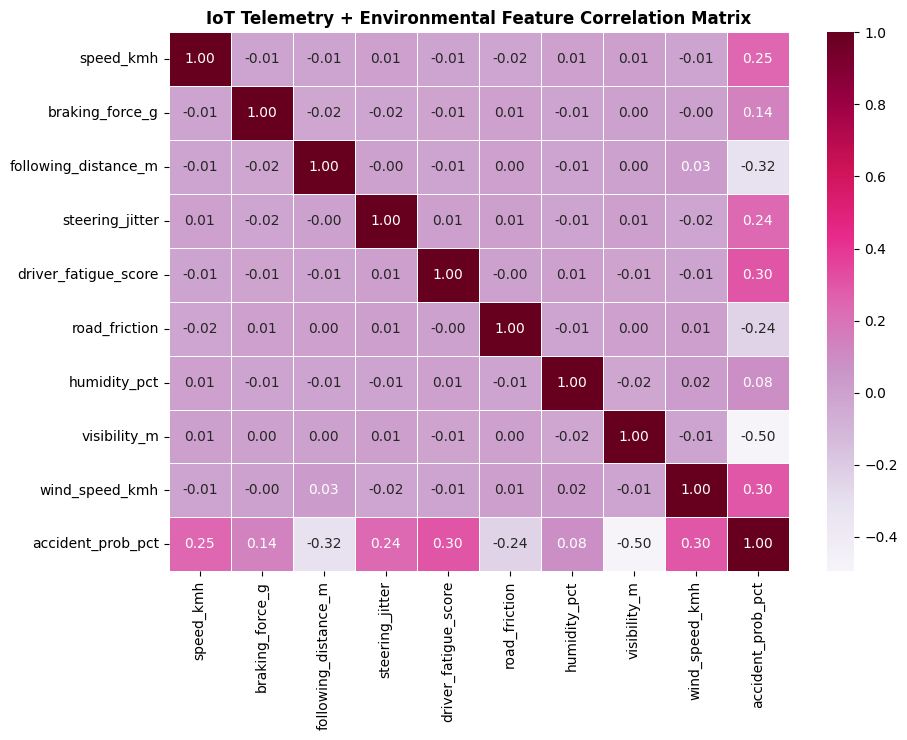

In [14]:
# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    df_iot.corr(),
    annot=True,
    fmt=".2f",
    cmap="PuRd",
    linewidths=0.5
)
plt.title("IoT Telemetry + Environmental Feature Correlation Matrix", fontsize=12, fontweight="bold")
plt.show()

## **Step 4: Preprocessing and train-test split**

In [9]:
X = df_iot.drop(columns=['accident_prob_pct']).values
y = df_iot['accident_prob_pct'].values

# Stratified-style random split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size:  {X_test_scaled.shape[0]} samples")

Training set size: 8000 samples
Testing set size:  2000 samples


## **Step 5: Model Training (Random Forest Regressor)**

In [10]:
# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train on scaled 8,000 samples
rf_model.fit(X_train_scaled, y_train)

# Predict on test set (2,000 samples)
y_pred = rf_model.predict(X_test_scaled)
print("Model training completed successfully.")

Model training completed successfully.


## **Step 6: Model Evaluation and Visualizations**

Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 5.121%
Mean Absolute Error (MAE):     4.000%
R-squared Score (R2):          0.9365


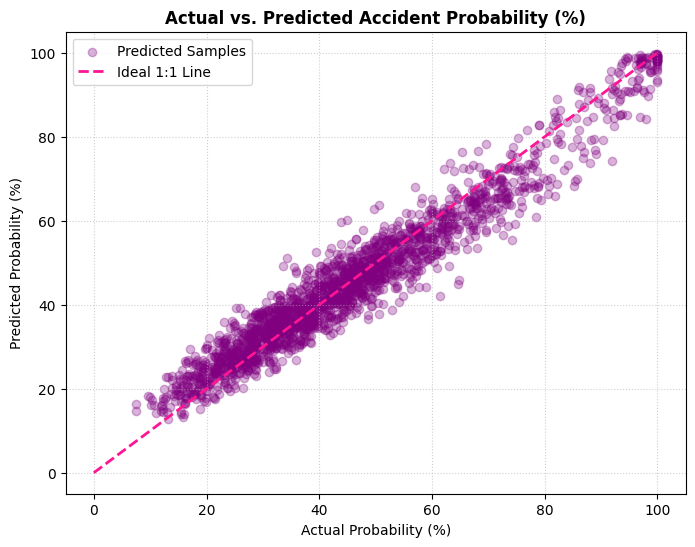

In [11]:
# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}%")
print(f"Mean Absolute Error (MAE):     {mae:.3f}%")
print(f"R-squared Score (R2):          {r2:.4f}")

# Plot Actual vs Predicted Probabilities
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="purple", label="Predicted Samples")
plt.plot([0, 100], [0, 100], color="deeppink", linestyle="--", linewidth=2, label="Ideal 1:1 Line")
plt.title("Actual vs. Predicted Accident Probability (%)", fontsize=12, fontweight="bold")
plt.xlabel("Actual Probability (%)")
plt.ylabel("Predicted Probability (%)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

## **Step 7: Live Real-Time IoT Sample Prediction Function**

In [12]:
def predict_live_iot_risk(telemetry_dict):
    # Convert input dictionary to array
    raw_input = np.array([[
        telemetry_dict['speed_kmh'],
        telemetry_dict['braking_force_g'],
        telemetry_dict['following_distance_m'],
        telemetry_dict['steering_jitter'],
        telemetry_dict['driver_fatigue_score'],
        telemetry_dict['road_friction'],
        telemetry_dict['humidity_pct'],
        telemetry_dict['visibility_m'],
        telemetry_dict['wind_speed_kmh']
    ]])

    scaled_input = scaler.transform(raw_input)
    predicted_prob = rf_model.predict(scaled_input)[0]
    return predicted_prob

# Simulate extreme adverse weather & risky driving live feed
sample_feed = {
    'speed_kmh': 135.0,
    'braking_force_g': 0.95,
    'following_distance_m': 12.0,
    'steering_jitter': 8.5,
    'driver_fatigue_score': 8.0,
    'road_friction': 0.25,      # Wet/Icy pavement
    'humidity_pct': 95.0,       # Torrential rain/fog
    'visibility_m': 45.0,       # Extremely poor visibility
    'wind_speed_kmh': 65.0      # High crosswind
}

live_risk = predict_live_iot_risk(sample_feed)
print("\nLIVE IoT SENSOR FEED PREDICTION:")
print(f"Calculated Accident Risk: {live_risk:.2f}%")

if live_risk > 70.0:
    print("ALERT LEVEL: CRITICAL - Automatic Emergency Braking / Driver Warning Triggered!")
elif live_risk > 40.0:
    print("ALERT LEVEL: WARNING - Advisory Speed Reduction Recommended.")
else:
    print("ALERT LEVEL: NORMAL - Conditions within Safe Parameters.")


LIVE IoT SENSOR FEED PREDICTION:
Calculated Accident Risk: 98.44%
ALERT LEVEL: CRITICAL - Automatic Emergency Braking / Driver Warning Triggered!


## **Feature Importance Analysis**

/tmp/ipykernel_1300/3107219784.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette="PuRd_r")


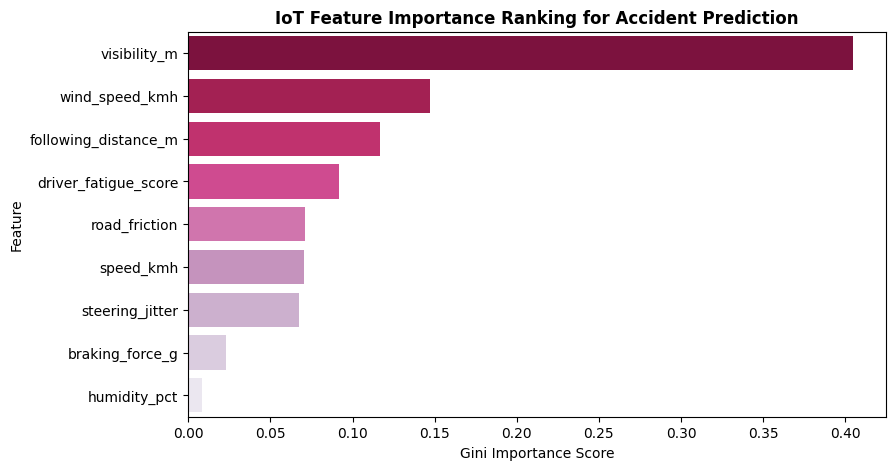

In [13]:
# Feature Importance Extraction
importances = rf_model.feature_importances_
feature_names = df_iot.columns[:-1]

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette="PuRd_r")
plt.title("IoT Feature Importance Ranking for Accident Prediction", fontweight="bold")
plt.xlabel("Gini Importance Score")
plt.show()